# Net-Hub: 대륙별 TV Show 콘텐츠 확보 우선순위 분석

> **발표 핵심 질문**  
> 글로벌 시청시간 확대 관점에서, 공급 대비 시청효율이 높은 **대륙 × 제작국가 × 장르 × TV Show** 세그먼트는 무엇인가?

---

## 요약

| 구분 | 핵심 질문 | 포인트 |
|---:|---|---|
| 1 | 왜 이 분석이 필요한가? | 콘텐츠 확보 의사결정은 공급량만으로 판단하기 어렵고, 실제 시청시간과 함께 봐야 한다. |
| 2 | 어떤 데이터를 쓰는가? | Kaggle은 카탈로그 공급 구조, Netflix 공식 보고서는 글로벌 시청시간을 제공한다. |
| 3 | 분석 범위는 왜 TV Show인가? | 공급 비중과 시청시간 비중을 비교해 TV Show의 시청 기여도를 먼저 확인한다. |
| 4 | 어떻게 연결하는가? | `title_key`를 정제해 두 데이터를 조인하고, 시즌 단위 시청시간은 시리즈 단위로 합산한다. |
| 5 | EDA는 무엇을 확인하는가? | 제작국가와 장르를 가중치로 분해해 TV Show 공급 구조를 확인한다. |
| 6 | 핵심 지표는 무엇인가? | `Efficiency Index = Watch Share / Supply Share`로 공급 대비 시청효율을 본다. |
| 7 | 결과를 어떻게 안정화하는가? | 매칭 타이틀 수와 단일 히트작 의존도를 함께 검토한다. |
| 8 | 최종 산출물은 무엇인가? | 대륙별 TV Show 확보 우선순위 Top 5와 비즈니스 액션을 제안한다. |

---

## 1. 데이터 역할 정리

| 데이터 | 실제 파일명 | 역할 | 핵심 컬럼 |
|---|---|---|---|
| Kaggle | `Netflix Movies and TV Shows` (`netflix_titles.csv`) | 공급 — 어떤 콘텐츠가 카탈로그에 존재하는가 | 제목, 제작국가, 장르, 유형, 등급 |
| Netflix 공식 | `What We Watched: A Netflix Engagement Report` | 수요 — 어떤 콘텐츠를 얼마나 봤는가 | 제목, 글로벌 시청시간 |

&nbsp;
> 이 분석에서 `country`는 **소비국가**가 아니라 **제작국가 / 제작 참여 국가**다.  
> 따라서 결과는 “어느 국가 사용자가 시청했는가”가 아니라  
> **"어느 제작국가 기반 TV Show가 글로벌 시청시간에서 높은 효율을 보였는가"**로 해석한다.

In [1]:
# ============================================================
# 0. 기본 라이브러리 로드
# ============================================================

# 데이터프레임 처리를 위한 라이브러리
import pandas as pd

# 수치 계산을 위한 라이브러리
import numpy as np

# 제목 정제를 위한 정규표현식 라이브러리
import re

# 파일 경로 처리를 위한 라이브러리
from pathlib import Path

# 시각화를 위한 라이브러리
import matplotlib.pyplot as plt

# 노트북 내 표와 설명 표시를 위한 함수
from IPython.display import display, Markdown

# 모델링 관련 라이브러리
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1-Pager의 모델 진화 흐름을 반영하기 위해 LightGBM Regressor 사용
from lightgbm import LGBMRegressor

# 경고 메시지 최소화
import warnings
warnings.filterwarnings("ignore")

# 그래프 기본 크기 설정
plt.rcParams["figure.figsize"] = (10, 5)

# 한글 깨짐을 피하기 위해 그래프 제목/축은 영어 중심으로 작성
plt.rcParams["axes.unicode_minus"] = False

In [2]:
# ============================================================
# 1. 데이터 파일 로드
# ============================================================

# 현재 폴더와 /mnt/data 경로에서 파일을 찾는 함수
def find_file(filename):
    # 현재 작업 폴더에 파일이 있으면 사용
    if Path(filename).exists():
        return Path(filename)
    # ChatGPT 환경의 /mnt/data에 파일이 있으면 사용
    if Path("/mnt/data", filename).exists():
        return Path("/mnt/data", filename)
    # 둘 다 없으면 에러 발생
    raise FileNotFoundError(f"{filename} 파일을 찾을 수 없습니다.")

# Kaggle Netflix 카탈로그 데이터 경로 지정
kaggle_path = find_file("netflix_titles.csv")

# Netflix 공식 Engagement Report 데이터 경로 지정
engagement_path = find_file("What_We_Watched_A_Netflix_Engagement_Report_2023Jan-Jun.xlsx")

# Kaggle 데이터 로드
netflix_raw = pd.read_csv(kaggle_path)

# Engagement Report는 상단 설명 행이 있어 header=5로 읽음
engagement_raw = pd.read_excel(engagement_path, header=5)

# 데이터 크기 확인
print(f"Kaggle Netflix Movies and TV Shows: {netflix_raw.shape[0]:,} rows × {netflix_raw.shape[1]:,} columns")
print(f"What We Watched Engagement Report: {engagement_raw.shape[0]:,} rows × {engagement_raw.shape[1]:,} columns")

Kaggle Netflix Movies and TV Shows: 8,807 rows × 12 columns
What We Watched Engagement Report: 18,214 rows × 5 columns


### 해석

- Kaggle 데이터는 **8,807개 콘텐츠의 카탈로그 메타데이터**를 제공하며, 제작국가·장르·유형·등급처럼 **공급 구조**를 설명하는 데 강점이 있다.
- Engagement Report는 **2023년 1~6월 글로벌 시청시간**을 제공하므로, 콘텐츠별 **수요/성과**를 확인하는 데 사용한다.
- 두 데이터는 시점과 목적이 다르지만 공통적으로 제목 정보를 가지고 있어 `title_key` 기준으로 연결할 수 있다.

**인사이트**  
이 단계에서 확인한 핵심은 “공급 데이터만으로는 콘텐츠 확보 우선순위를 정하기 어렵다”는 점이다.      
따라서 이후 분석은 Kaggle 데이터로 공급 구조를 만들고, Engagement Report로 시청시간을 붙여 **공급 대비 시청효율**을 확인하는 방향으로 진행한다.

## 2. TV Show 중심 분석 범위 설정

분석 범위는 데이터 점검 결과에 따라 TV Show 중심으로 설정한다.  
먼저 전체 카탈로그에서 Movie와 TV Show가 각각 어느 정도 공급되어 있고,  
Engagement Report와 조인했을 때 시청시간이 어느 유형에 집중되는지 확인한다.

확인 기준은 다음과 같다.

1. Kaggle 카탈로그의 Movie / TV Show 공급 비중
2. Engagement Report와 매칭된 Movie / TV Show 매칭률
3. 매칭 콘텐츠 기준 글로벌 시청시간 비중

In [3]:
# ============================================================
# 2. title_key 정제 함수 정의
# ============================================================

def make_title_key(title):
    # 입력값을 문자열로 바꾸고 소문자로 통일
    title = str(title).lower()

    # Engagement Report의 다국어 제목 구분자(//) 뒤쪽은 제거
    title = title.split("//")[0]

    # ": Season 1", "- Part 2"처럼 시즌/파트가 붙은 표현 제거
    title = re.sub(
        r"[:\-–—]\s*(season|series|part|chapter|volume|book|limited series|collection)\s*[\w\d]+.*$",
        "",
        title
    )

    # 문장 중간의 "season 1", "part 2" 같은 표현 제거
    title = re.sub(r"\b(season|series|part|chapter|volume|book)\s*\d+\b", "", title)

    # "limited series" 표현 제거
    title = re.sub(r"\blimited series\b", "", title)

    # 영어, 숫자, 한글, 공백을 제외한 특수문자는 공백으로 변환
    title = re.sub(r"[^a-z0-9\s가-힣]", " ", title)

    # 여러 개 공백을 하나로 줄이고 앞뒤 공백 제거
    title = re.sub(r"\s+", " ", title).strip()

    # 최종 정제된 key 반환
    return title

# 원본 데이터 복사
netflix = netflix_raw.copy()
engagement = engagement_raw.copy()

# Engagement Report에서 제목이 없는 행 제거
engagement = engagement.dropna(subset=["Title"]).copy()

# Kaggle 데이터 title_key 생성
netflix["title_key"] = netflix["title"].apply(make_title_key)

# Engagement Report title_key 생성
engagement["title_key"] = engagement["Title"].apply(make_title_key)

# 시즌/파트 단위로 나뉜 시청시간을 시리즈 단위 title_key로 합산
engagement_title = (
    engagement
    .groupby("title_key", as_index=False)
    .agg(
        hours_viewed=("Hours Viewed", "sum"),
        engagement_rows=("Title", "count")
    )
)

# title_key 기준으로 Kaggle 데이터와 Engagement Report 병합
merged_all = netflix.merge(engagement_title, on="title_key", how="left")

# Movie / TV Show별 공급량, 매칭 수, 시청시간 집계
type_summary = (
    merged_all
    .groupby("type")
    .agg(
        supply_titles=("show_id", "count"),
        matched_titles=("hours_viewed", "count"),
        watch_hours=("hours_viewed", "sum")
    )
    .fillna(0)
)

# 공급 비중 계산
type_summary["supply_share"] = type_summary["supply_titles"] / type_summary["supply_titles"].sum()

# 시청시간 비중 계산
type_summary["watch_share"] = type_summary["watch_hours"] / type_summary["watch_hours"].sum()

# 매칭률 계산
type_summary["match_rate"] = type_summary["matched_titles"] / type_summary["supply_titles"]

# 보기 좋은 출력용 테이블 생성
type_summary_display = type_summary.copy()
type_summary_display["supply_share"] = (type_summary_display["supply_share"] * 100).round(1).astype(str) + "%"
type_summary_display["watch_share"] = (type_summary_display["watch_share"] * 100).round(1).astype(str) + "%"
type_summary_display["match_rate"] = (type_summary_display["match_rate"] * 100).round(1).astype(str) + "%"
type_summary_display["watch_hours"] = type_summary_display["watch_hours"].map(lambda x: f"{x:,.0f}")

# 결과 출력
display(type_summary_display)

,supply_titles,matched_titles,watch_hours,supply_share,watch_share,match_rate
type,,,,,,
Movie,6131,2872,"6,677,700,000",69.6%,15.9%,46.8%
TV Show,2676,1695,"35,198,800,000",30.4%,84.1%,63.3%


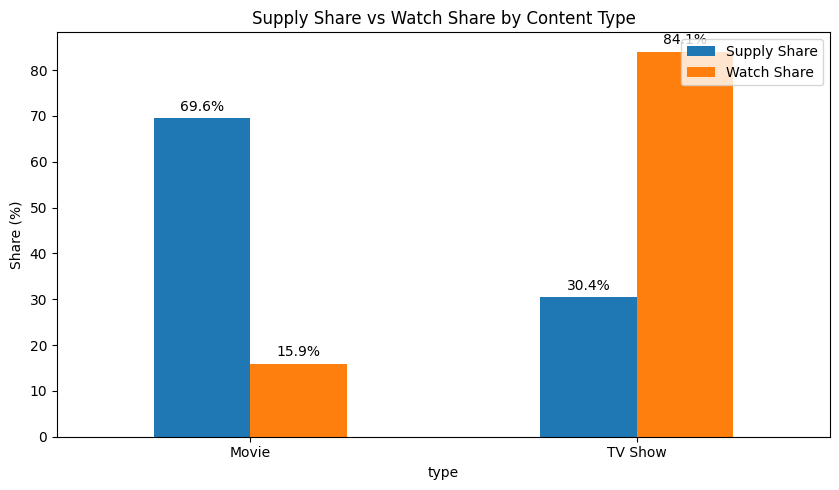

In [4]:
# ============================================================
# 3. Movie vs TV Show 공급 비중과 시청시간 비중 시각화
# ============================================================

# 시각화용 데이터 준비
type_plot = type_summary[["supply_share", "watch_share"]].copy() * 100

# 막대 그래프 생성
ax = type_plot.plot(kind="bar", figsize=(8.5, 5))

# 그래프 제목 설정
plt.title("Supply Share vs Watch Share by Content Type")

# y축 라벨 설정
plt.ylabel("Share (%)")

# x축 라벨 회전 제거
plt.xticks(rotation=0)

# 범례 설정
plt.legend(["Supply Share", "Watch Share"], loc="upper right")

# 각 막대 위에 수치 표시
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

# 레이아웃 정리
plt.tight_layout()

# 그래프 출력
plt.show()

### 해석 및 분석 범위

- 전체 카탈로그 공급량 기준으로는 **Movie가 약 69.6%**, **TV Show가 약 30.4%**를 차지한다.
- 반면 Engagement Report와 조인한 시청시간 기준으로는 **TV Show가 약 84.1%**를 차지한다.
- Movie는 공급량이 많지만 시청시간 비중은 상대적으로 낮고, TV Show는 공급량보다 시청시간 비중이 훨씬 높다.

**인사이트**  
이 결과는 TV Show가 전체 카탈로그 내 공급량은 작지만, 글로벌 시청시간에서는 훨씬 큰 기여를 하고 있음을 보여준다.     
따라서 이후 분석은 단순히 “콘텐츠가 많이 깔린 영역”이 아니라, **공급 대비 시청시간 격차가 크게 나타나는 TV Show 영역**에 집중한다.

**다음 분석 연결**  
TV Show 중심으로 좁힌 뒤, 어떤 제작국가와 장르가 높은 시청효율을 만드는지 보기 위해 `country`, `listed_in`을 가중치 방식으로 분해한다.

## 3. title_key 정제와 조인 기준

두 데이터는 모두 제목 컬럼을 가지고 있지만 표기 방식이 다르다.  
따라서 직접 조인하지 않고 `title_key`를 만들어 조인한다.

| 처리 | 이유 |
|---|---|
| 소문자 변환 | 대소문자 차이 제거 |
| `//` 뒤 다국어 제목 제거 | 동일 콘텐츠의 언어별 제목 표기 차이 완화 |
| `Season`, `Part`, `Limited Series` 표현 제거 | 시즌 단위 시청시간을 시리즈 단위로 합산 |
| 특수문자 제거 | 콜론, 하이픈, 괄호 등 표기 차이 완화 |
| 공백 정리 | 불필요한 공백으로 인한 미매칭 방지 |

이 조인 방식은 “콘텐츠명(title_key) 기준 병합”을 구현한 것이다.

In [5]:
# ============================================================
# 4. 조인 결과 요약
# ============================================================

# 전체 Kaggle 콘텐츠 수
total_kaggle_titles = len(merged_all)

# Engagement Report와 매칭된 Kaggle 콘텐츠 수
matched_kaggle_titles = merged_all["hours_viewed"].notna().sum()

# Kaggle 기준 매칭률
kaggle_match_rate = matched_kaggle_titles / total_kaggle_titles

# Engagement Report의 고유 title_key 수
engagement_unique_keys = engagement_title["title_key"].nunique()

# Engagement Report title_key 중 Kaggle과 매칭된 수
matched_engagement_keys = engagement_title["title_key"].isin(netflix["title_key"]).sum()

# Engagement Report 기준 매칭률
engagement_match_rate = matched_engagement_keys / engagement_unique_keys

# 조인 요약 테이블 생성
join_summary = pd.DataFrame({
    "metric": [
        "Kaggle titles",
        "Matched Kaggle titles",
        "Kaggle match rate",
        "Engagement unique title keys",
        "Matched Engagement title keys",
        "Engagement title-key match rate"
    ],
    "value": [
        f"{total_kaggle_titles:,}",
        f"{matched_kaggle_titles:,}",
        f"{kaggle_match_rate:.1%}",
        f"{engagement_unique_keys:,}",
        f"{matched_engagement_keys:,}",
        f"{engagement_match_rate:.1%}"
    ]
})

# 결과 출력
display(join_summary)

,metric,value
0,Kaggle titles,"8,807"
1,Matched Kaggle titles,"4,567"
2,Kaggle match rate,51.9%
3,Engagement unique title keys,"15,293"
4,Matched Engagement title keys,"4,548"
5,Engagement title-key match rate,29.7%


### 해석

- 1-Pager의 1차 KPI는 **Kaggle↔Engagement title_key 매칭률 25% 이상**이다.
- 정제된 `title_key` 기준으로 Kaggle 8,807개 중 **4,567개가 매칭**되어, Kaggle 기준 매칭률은 **51.9%**로 확인된다.
- Engagement Report의 고유 title_key 기준으로는 **15,293개 중 4,548개가 매칭**되어, Engagement 기준 매칭률은 **29.7%**로 확인된다.

**인사이트**  
Kaggle 기준 매칭률이 25%를 넘기 때문에, 공급 데이터와 시청시간 데이터를 결합한 분석은 가능하다.     
다만 두 데이터의 기준 시점이 다르므로, 분석 범위는 “2021년까지의 Kaggle 카탈로그 중 2023년 상반기에도 시청시간이 확인된 콘텐츠”로 제한된다.

**다음 분석 연결**  
조인이 가능한 범위가 확인되었으므로, 다음 단계에서는 TV Show의 제작국가·장르 정보를 정교하게 나누어 세그먼트별 공급량과 시청시간을 계산한다.

## 4. 국가·장르 다중값 처리: explode + weight

Kaggle 데이터의 `country`, `listed_in`은 한 콘텐츠에 여러 값이 들어갈 수 있다.

예를 들어 다음과 같은 경우가 존재한다.

- `country = United States, India`
- `listed_in = Dramas, International TV Shows`

첫 번째 값만 사용하면 뒤쪽 정보가 사라지고,  
모든 값을 1개씩 카운트하면 콘텐츠 1개가 여러 번 중복 계산된다.

따라서 이번 분석에서는 다음 방식으로 처리한다.

```text
국가가 2개인 콘텐츠 → 각 국가에 0.5씩 부여
장르가 3개인 콘텐츠 → 각 장르에 1/3씩 부여
국가 2개 × 장르 3개 → 각 국가×장르 조합에 1/6씩 부여
```

이렇게 하면 콘텐츠 하나의 총 공급량은 항상 1로 유지된다.

In [6]:
# ============================================================
# 5. 다중 국가·다중 장르 원본 예시 확인
# ============================================================

# country 또는 listed_in에 쉼표가 포함된 행만 추출
multi_value_examples = (
    netflix_raw[
        netflix_raw["country"].fillna("").str.contains(",") |
        netflix_raw["listed_in"].fillna("").str.contains(",")
    ][["title", "type", "country", "listed_in"]]
    .head(5)
)

# 원본 형태 출력
display(multi_value_examples)

,title,type,country,listed_in
1,Blood & Water,TV Show,South Africa,"International TV Shows, TV Dramas, TV Mysteries"
2,Ganglands,TV Show,NaN,"Crime TV Shows, International TV Shows, TV Act..."
3,Jailbirds New Orleans,TV Show,NaN,"Docuseries, Reality TV"
4,Kota Factory,TV Show,India,"International TV Shows, Romantic TV Shows, TV ..."
5,Midnight Mass,TV Show,NaN,"TV Dramas, TV Horror, TV Mysteries"


### 해석 : 다중값 컬럼 확인

- 일부 콘텐츠는 `country`와 `listed_in`에 여러 값이 동시에 기록되어 있다.
- 이 구조를 그대로 두면 국가·장르별 공급량을 계산할 때 기준이 흔들린다.
- 예를 들어 공동 제작 콘텐츠를 첫 번째 국가에만 배정하면 뒤쪽 제작국가가 과소평가되고, 모든 국가를 1개씩 세면 총 공급량이 실제보다 커진다.

**다음 분석 연결**  
따라서 다음 단계에서는 국가와 장르를 모두 분해하되, 각 값에 가중치를 부여해 콘텐츠 1개의 총합이 1이 되도록 조정한다.

In [7]:
# ============================================================
# 6. TV Show 데이터 필터링 및 explode + weight 처리
# ============================================================

# TV Show만 분석 대상으로 필터링
tv = merged_all[merged_all["type"] == "TV Show"].copy()

# date_added를 날짜형으로 변환
tv["date_added_dt"] = pd.to_datetime(tv["date_added"], errors="coerce")

# 공개연도와 등록연도 생성
tv["release_year_num"] = pd.to_numeric(tv["release_year"], errors="coerce")
tv["year_added"] = tv["date_added_dt"].dt.year

# 콘텐츠 등록 시점의 나이 계산
tv["content_age_when_added"] = tv["year_added"] - tv["release_year_num"]

# rating을 상위 그룹으로 묶는 함수 정의
def map_rating_group(rating):
    # 결측은 Unknown
    if pd.isna(rating):
        return "Unknown"
    # 문자열 공백 제거
    rating = str(rating).strip()
    # 어린이/가족 시청 등급
    if rating in ["TV-Y", "TV-Y7", "TV-G", "G"]:
        return "Kids"
    # 청소년/가족 동반 시청 등급
    if rating in ["TV-PG", "TV-14", "PG", "PG-13"]:
        return "Teens"
    # 성인 등급
    if rating in ["TV-MA", "R", "NC-17"]:
        return "Adults"
    # 미분류
    if rating in ["NR", "UR", "Unknown"]:
        return "Not Rated"
    # 기타
    return "Other"

# rating_group 생성
tv["rating_group"] = tv["rating"].apply(map_rating_group)

# country가 비어 있으면 Unknown으로 처리하고 쉼표 기준 리스트로 분리
tv["country_list"] = tv["country"].fillna("Unknown").apply(lambda x: [v.strip() for v in str(x).split(",") if v.strip()])

# listed_in이 비어 있으면 Unknown으로 처리하고 쉼표 기준 리스트로 분리
tv["genre_list"] = tv["listed_in"].fillna("Unknown").apply(lambda x: [v.strip() for v in str(x).split(",") if v.strip()])

# 한 콘텐츠에 포함된 제작국가 수 계산
tv["country_n"] = tv["country_list"].apply(len)

# 한 콘텐츠에 포함된 장르 수 계산
tv["genre_n"] = tv["genre_list"].apply(len)

# 제작국가 가중치 계산
tv["country_weight"] = 1 / tv["country_n"]

# 장르 가중치 계산
tv["genre_weight"] = 1 / tv["genre_n"]

# 국가와 장르를 모두 분해하여 국가×장르 조합 단위로 확장
tv_expanded = tv.explode("country_list").explode("genre_list").copy()

# 분석 목적에 맞게 컬럼명 변경
tv_expanded = tv_expanded.rename(columns={
    "country_list": "production_country",
    "genre_list": "genre"
})

# 국가×장르 조합 가중치 계산
tv_expanded["segment_weight"] = tv_expanded["country_weight"] * tv_expanded["genre_weight"]

# 매칭되지 않은 시청시간은 0으로 처리
tv_expanded["hours_viewed_filled"] = tv_expanded["hours_viewed"].fillna(0)

# 세그먼트별로 배분된 시청시간 계산
tv_expanded["weighted_watch_hours"] = tv_expanded["hours_viewed_filled"] * tv_expanded["segment_weight"]

# 가공 결과 예시 확인
display(tv_expanded[[
    "title", "production_country", "genre", "rating_group",
    "release_year_num", "year_added", "segment_weight",
    "hours_viewed", "weighted_watch_hours"
]].head(10))

,title,production_country,genre,rating_group,release_year_num,year_added,segment_weight,hours_viewed,weighted_watch_hours
1,Blood & Water,South Africa,International TV Shows,Adults,2021,2021.0,0.333333,27200000.0,9.066667e+06
1,Blood & Water,South Africa,TV Dramas,Adults,2021,2021.0,0.333333,27200000.0,9.066667e+06
1,Blood & Water,South Africa,TV Mysteries,Adults,2021,2021.0,0.333333,27200000.0,9.066667e+06
2,Ganglands,Unknown,Crime TV Shows,Adults,2021,2021.0,0.333333,85300000.0,2.843333e+07
2,Ganglands,Unknown,International TV Shows,Adults,2021,2021.0,0.333333,85300000.0,2.843333e+07
2,Ganglands,Unknown,TV Action & Adventure,Adults,2021,2021.0,0.333333,85300000.0,2.843333e+07
3,Jailbirds New Orleans,Unknown,Docuseries,Adults,2021,2021.0,0.500000,2000000.0,1.000000e+06
3,Jailbirds New Orleans,Unknown,Reality TV,Adults,2021,2021.0,0.500000,2000000.0,1.000000e+06
4,Kota Factory,India,International TV Shows,Adults,2021,2021.0,0.333333,2400000.0,8.000000e+05
4,Kota Factory,India,Romantic TV Shows,Adults,2021,2021.0,0.333333,2400000.0,8.000000e+05


### 해석

이 단계에서는 1-Pager의 핵심 피처군을 실제 분석 테이블에 반영했다.

| 핵심 피처군 | 반영 방식 | 분석상 의미 |
|---|---|---|
| 제작국가 가중치 | `country_weight`, `production_country` | 공동 제작 콘텐츠의 국가 기여도를 나누어 계산 |
| 장르 가중치 | `genre_weight`, `genre` | 복합 장르 콘텐츠의 장르 기여도를 나누어 계산 |
| 콘텐츠 유형 | `type` | TV Show 중심 분석 범위를 명확히 설정 |
| 등급 그룹 | `rating_group` | 콘텐츠의 주요 타깃 연령대를 보조 피처로 활용 |
| 공개년도/등록년도 | `release_year_num`, `year_added`, `content_age_when_added` | 콘텐츠 최신성·라이브러리성을 확인 |
| 글로벌 시청시간 | `hours_viewed`, `weighted_watch_hours` | 수요/성과 지표로 활용 |

**인사이트**  
첫 번째 값만 대표값으로 사용하면 공동 제작 국가나 복합 장르 정보가 사라진다.      
 반대로 모든 국가·장르를 1개씩 세면 콘텐츠 1개가 여러 번 계산된다.        
 그래서 이번 분석은 `explode + weight` 방식으로 **정보 손실과 과대 계산을 동시에 줄이는 구조**를 만들었다.

**다음 분석 연결**  
이제 가중치 기반 공급량과 시청시간을 계산할 수 있으므로, 제작국가별·장르별 공급 구조를 먼저 확인한다.

## 5. EDA: 제작국가·장르 공급 구조 확인

Efficiency Index를 계산하기 전에 먼저 TV Show의 공급 구조를 확인한다.  
이 단계의 목적은 다음과 같다.

1. 어떤 제작국가가 TV Show 공급에서 큰 비중을 차지하는가?
2. 어떤 장르가 TV Show 공급에서 큰 비중을 차지하는가?
3. 공급량이 많은 세그먼트와 시청시간이 높은 세그먼트가 같은가?

공급 구조를 먼저 확인해야 이후 시청시간과 비교했을 때  
**“많이 공급되어 많이 본 것인지”**, **“공급은 적지만 많이 본 것인지”**를 구분할 수 있다.

In [8]:
# ============================================================
# 7. 제작국가별 TV Show 공급 구조
# ============================================================

# 제작국가별 가중 공급량 집계
country_supply = (
    tv_expanded
    .groupby("production_country", as_index=False)
    .agg(supply_weight=("segment_weight", "sum"))
    .sort_values("supply_weight", ascending=False)
)

# 상위 12개 제작국가 확인
top_country_supply = country_supply.head(12)

# 결과 표 출력
display(top_country_supply)

,production_country,supply_weight
62,United States,837.225000
63,Unknown,391.000000
61,United Kingdom,238.075000
29,Japan,180.658333
51,South Korea,163.083333
7,Canada,87.950000
24,India,80.783333
56,Taiwan,69.000000
18,France,64.491667
1,Australia,55.325000


### 해석 : 제작국가별 공급 구조

- 미국의 가중 공급량은 **837.2**로 가장 크며, TV Show 공급 구조에서 가장 큰 축을 형성한다.
- 그다음은 **United Kingdom(238.1)**, **Japan(180.7)**, **South Korea(163.1)** 순으로 나타난다.
- `Unknown`도 상위에 존재하므로, 일부 콘텐츠는 제작국가 정보가 충분히 식별되지 않았다는 점을 함께 고려해야 한다.

**인사이트**  
미국 중심 공급 구조는 명확하지만, 일본·한국·영국도 TV Show 카탈로그에서 충분히 큰 공급 기반을 가지고 있다.      
이후 시청시간을 결합했을 때 이 국가들이 공급 대비 높은 성과를 보이는지 확인할 필요가 있다.

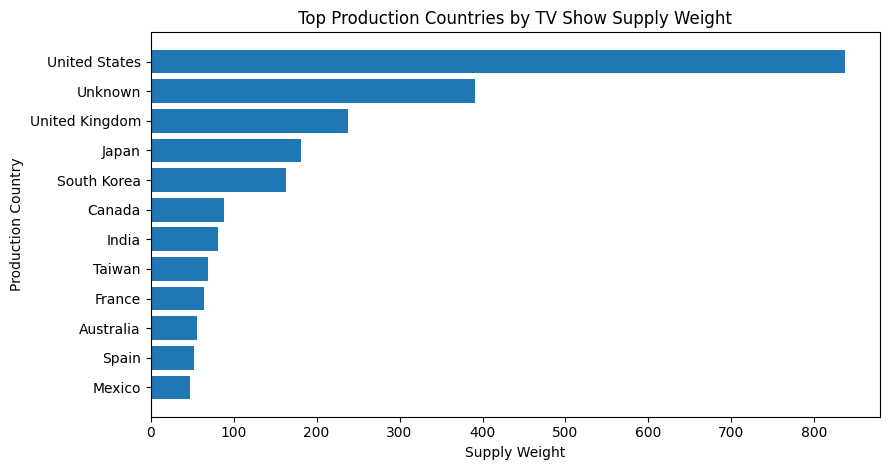

In [9]:
# ============================================================
# 8. 제작국가별 공급 구조 시각화
# ============================================================

# 막대 그래프 생성
plt.figure(figsize=(9, 4.8))
plt.barh(top_country_supply["production_country"][::-1], top_country_supply["supply_weight"][::-1])

# 그래프 제목과 축 설정
plt.title("Top Production Countries by TV Show Supply Weight")
plt.xlabel("Supply Weight")
plt.ylabel("Production Country")

# 레이아웃 정리
plt.tight_layout()

# 그래프 출력
plt.show()

### 해석 : 제작국가별 공급 집중도

- 그래프는 TV Show 공급이 미국에 크게 집중되어 있음을 시각적으로 보여준다.
- 동시에 영국·일본·한국이 미국 다음의 핵심 공급국으로 나타나, 단순히 미국만 보는 분석보다 국가별 비교가 필요함을 보여준다.

**다음 분석 연결**  
공급 구조가 특정 국가에 집중되어 있기 때문에, 단순 시청시간만 비교하면 공급량이 큰 국가가 유리해질 수 있다.      
따라서 이후에는 공급 비중을 보정한 EI 지표가 필요하다.

In [10]:
# ============================================================
# 9. 장르별 TV Show 공급 구조
# ============================================================

# 장르별 가중 공급량 집계
genre_supply = (
    tv_expanded
    .groupby("genre", as_index=False)
    .agg(supply_weight=("segment_weight", "sum"))
    .sort_values("supply_weight", ascending=False)
)

# 상위 12개 장르 확인
top_genre_supply = genre_supply.head(12)

# 결과 표 출력
display(top_genre_supply)

,genre,supply_weight
5,International TV Shows,505.500000
6,Kids' TV,326.666667
15,TV Dramas,311.166667
14,TV Comedies,277.666667
4,Docuseries,215.166667
3,Crime TV Shows,169.000000
8,Reality TV,162.166667
9,Romantic TV Shows,128.333333
1,British TV Shows,93.000000
0,Anime Series,85.333333


### 해석 : 장르별 공급 구조

- `International TV Shows`의 가중 공급량은 **505.5**로 가장 크다.
- 그다음은 `Kids' TV(326.7)`, `TV Dramas(311.2)`, `TV Comedies(277.7)`, `Docuseries(215.2)` 순이다.
- 즉, TV Show 공급은 국제 콘텐츠와 드라마·코미디·키즈 계열이 주요 축을 이룬다.

**인사이트**  
공급량이 큰 장르는 이미 카탈로그에 많이 확보된 장르다.        
따라서 추가 확보 우선순위를 판단하려면 “많이 공급된 장르”가 아니라 “공급 대비 시청시간이 높은 장르”를 찾아야 한다.

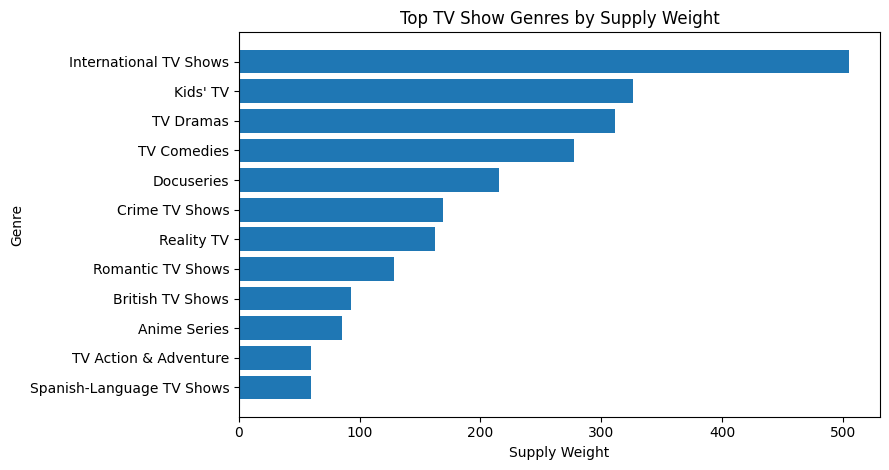

In [11]:
# ============================================================
# 10. 장르별 공급 구조 시각화
# ============================================================

# 막대 그래프 생성
plt.figure(figsize=(9, 4.8))
plt.barh(top_genre_supply["genre"][::-1], top_genre_supply["supply_weight"][::-1])

# 그래프 제목과 축 설정
plt.title("Top TV Show Genres by Supply Weight")
plt.xlabel("Supply Weight")
plt.ylabel("Genre")

# 레이아웃 정리
plt.tight_layout()

# 그래프 출력
plt.show()

### 해석 : 장르별 공급량 비교

- `International TV Shows`가 가장 큰 공급 축으로 보이며, `Kids' TV`, `TV Dramas`, `TV Comedies`가 뒤를 따른다.
- 장르별 공급량의 차이가 크기 때문에 단순 시청시간 비교만으로는 장르 성과를 공정하게 판단하기 어렵다.

**다음 분석 연결**  
공급량 차이를 보정하기 위해, 다음 단계에서 `Watch Share / Supply Share` 기반의 Efficiency Index를 계산한다.

### EDA 해석

- 제작국가 기준으로는 **United States(837.2)**가 가장 크고, 그 뒤로 **United Kingdom(238.1)**, **Japan(180.7)**, **South Korea(163.1)**가 이어진다.
- 장르 기준으로는 **International TV Shows(505.5)**가 가장 크며, **Kids' TV(326.7)**, **TV Dramas(311.2)**, **TV Comedies(277.7)**가 뒤를 따른다.
- 즉, TV Show 공급은 미국 중심으로 크지만, 영국·일본·한국도 의미 있는 공급 축을 형성하고 있다.

**인사이트**  
공급량만 보면 미국과 International TV Shows가 가장 강하게 보인다.       
그러나 공급량이 많다는 것은 “이미 많이 확보되어 있다”는 뜻일 수도 있다.       
콘텐츠 확보 우선순위를 정하려면 공급량뿐 아니라 실제 시청시간 비중을 함께 봐야 한다.

**다음 분석 연결**  
따라서 다음 단계에서는 `Supply Share`와 `Watch Share`를 비교하는 **Efficiency Index**를 계산해, 공급 대비 시청효율이 높은 세그먼트를 찾는다.

## 6. 핵심 지표: Efficiency Index

### 지표 정의

```text
Efficiency Index = Watch Share / Supply Share
```

| 값 | 해석 |
|---:|---|
| EI > 1 | 공급 비중보다 시청 비중이 높음 |
| EI = 1 | 공급 비중과 시청 비중이 유사함 |
| EI < 1 | 공급 비중보다 시청 비중이 낮음 |
| EI ≥ 1.5 | 공급 대비 시청효율이 뚜렷한 후보 |

예를 들어 공급 비중이 2%인 세그먼트가 전체 시청시간의 6%를 차지한다면,  
EI는 3.0이다. 즉, 공급량 대비 3배의 시청시간 비중을 보인다는 뜻이다.

### 기준선 1.5의 의미

EI 1.0은 공급 비중만큼 시청된 상태다.  
EI 1.5는 공급 대비 최소 50% 이상 높은 시청 비중을 보였다는 의미이므로,  
1-Pager의 “고효율 세그먼트 후보” 기준으로 사용한다.

In [12]:
# ============================================================
# 11. 세그먼트별 공급·시청시간·Efficiency Index 계산
# ============================================================

# 국가×장르×유형 세그먼트 기준으로 집계
segment = (
    tv_expanded
    .groupby(["production_country", "genre", "type"], as_index=False)
    .agg(
        supply_weight=("segment_weight", "sum"),
        watch_hours=("weighted_watch_hours", "sum"),
        matched_titles=("hours_viewed", lambda x: x.notna().sum()),
        dominant_rating_group=("rating_group", lambda x: x.value_counts().idxmax()),
        median_release_year=("release_year_num", "median"),
        median_year_added=("year_added", "median"),
        median_content_age=("content_age_when_added", "median")
    )
)

# 전체 TV Show 공급량 계산
total_supply = segment["supply_weight"].sum()

# 전체 TV Show 시청시간 계산
total_watch = segment["watch_hours"].sum()

# 공급 비중 계산
segment["supply_share"] = segment["supply_weight"] / total_supply

# 시청시간 비중 계산
segment["watch_share"] = segment["watch_hours"] / total_watch

# Efficiency Index 계산
segment["efficiency_index"] = segment["watch_share"] / segment["supply_share"]

# 시청시간이 없는 세그먼트는 EI를 0으로 처리
segment["efficiency_index"] = segment["efficiency_index"].replace([np.inf, -np.inf], np.nan).fillna(0)

# 결과 확인
display(segment.sort_values("efficiency_index", ascending=False).head(10))

,production_country,genre,type,supply_weight,watch_hours,matched_titles,dominant_rating_group,median_release_year,median_year_added,median_content_age,supply_share,watch_share,efficiency_index
347,Poland,TV Action & Adventure,TV Show,0.166667,2.748333e+07,1,Adults,2019.0,2019.0,0.0,0.000062,0.000781,12.536575
498,United States,Romantic TV Shows,TV Show,16.527778,2.181792e+09,28,Teens,2019.0,2020.0,0.0,0.006176,0.061985,10.035917
103,Colombia,TV Action & Adventure,TV Show,0.111111,1.395556e+07,1,Adults,2017.0,2017.0,0.0,0.000042,0.000396,9.548780
285,Malta,TV Dramas,TV Show,0.083333,8.341667e+06,1,Adults,2018.0,2020.0,2.0,0.000031,0.000237,7.610134
283,Malta,Crime TV Shows,TV Show,0.083333,8.341667e+06,1,Adults,2018.0,2020.0,2.0,0.000031,0.000237,7.610134
284,Malta,TV Action & Adventure,TV Show,0.083333,8.341667e+06,1,Adults,2018.0,2020.0,2.0,0.000031,0.000237,7.610134
252,Japan,TV Action & Adventure,TV Show,1.458333,1.018458e+08,4,Adults,2018.0,2018.0,0.0,0.000545,0.002893,5.309391
509,United States,TV Thrillers,TV Show,9.027778,5.735000e+08,18,Adults,2019.0,2020.0,0.0,0.003374,0.016293,4.829596
256,Japan,TV Mysteries,TV Show,1.333333,8.446667e+07,4,Adults,2019.0,2019.0,0.0,0.000498,0.002400,4.816204
232,Italy,British TV Shows,TV Show,0.166667,9.166667e+06,1,Adults,2021.0,2021.0,0.0,0.000062,0.000260,4.181393


### 해석 : Efficiency Index 상위 세그먼트

- EI만 기준으로 보면 Poland, Colombia, Malta, Japan처럼 공급량이 작은 세그먼트도 상위에 나타날 수 있다.
- 이는 공급 비중이 작으면 작은 시청시간 증가에도 EI가 크게 튈 수 있기 때문이다.
- 반면 미국 `Romantic TV Shows`, `TV Dramas`, `TV Action & Adventure`처럼 시청시간 규모와 EI가 함께 높은 후보도 존재한다.

**인사이트**  
EI는 공급 대비 효율을 찾는 데 유용하지만, 표본 수와 시청시간 규모를 함께 보지 않으면 작은 세그먼트를 과대평가할 수 있다.      
그래서 다음 단계에서 매칭 타이틀 수와 단일 히트작 의존도를 결합해 안정성을 보완한다.

## 7. 민감도 분석: 단일 히트작 의존도

EI가 높더라도 특정 작품 1개가 세그먼트 전체 시청시간의 대부분을 차지한다면  
그 세그먼트는 안정적인 확보 후보라고 보기 어렵다.

따라서 다음 지표를 함께 본다.

```text
Top-title Dependency = 세그먼트 내 1위 타이틀 시청시간 / 세그먼트 전체 시청시간
```

| 값 | 해석 |
|---:|---|
| 0~40% | 비교적 안정적 |
| 40~60% | 일부 인기작 영향 있음 |
| 60% 이상 | 단일 히트작 의존도가 높아 주의 필요 |

이번 분석에서는 **60%**를 주의 기준선으로 둔다.

In [13]:
# ============================================================
# 12. 세그먼트별 단일 히트작 의존도 계산
# ============================================================

# 타이틀 단위 세그먼트 기여도 계산
title_segment = (
    tv_expanded
    .groupby(["production_country", "genre", "type", "title_key"], as_index=False)
    .agg(title_watch_hours=("weighted_watch_hours", "sum"))
)

# 세그먼트별 최대 타이틀 시청시간 계산
top_title = (
    title_segment
    .groupby(["production_country", "genre", "type"], as_index=False)
    .agg(top_title_hours=("title_watch_hours", "max"))
)

# 세그먼트 테이블에 최대 타이틀 시청시간 병합
segment = segment.merge(top_title, on=["production_country", "genre", "type"], how="left")

# 단일 히트작 의존도 계산
segment["top_title_dependency"] = segment["top_title_hours"] / segment["watch_hours"]

# 시청시간이 0인 세그먼트는 의존도 0으로 처리
segment["top_title_dependency"] = segment["top_title_dependency"].replace([np.inf, -np.inf], np.nan).fillna(0)

# EI 극단값 영향을 줄이기 위해 10에서 상한 처리
segment["efficiency_capped"] = segment["efficiency_index"].clip(upper=10)

# rank_score 계산: 효율성 × 근거 규모 × 안정성
segment["rank_score"] = (
    segment["efficiency_capped"]
    * np.log1p(segment["matched_titles"])
    * (1 - segment["top_title_dependency"])
)

# 최소 분석 기준 적용
segment_valid = segment[
    (segment["matched_titles"] >= 2) &
    (segment["watch_hours"] > 0)
].copy()

# 근거 수준 부여
def evidence_level(row):
    if row["matched_titles"] >= 10 and row["top_title_dependency"] <= 0.6:
        return "Strong"
    if row["matched_titles"] >= 5 and row["top_title_dependency"] <= 0.7:
        return "Moderate"
    return "Exploratory"

segment_valid["evidence_level"] = segment_valid.apply(evidence_level, axis=1)

# 결과 확인
display(segment_valid.sort_values("rank_score", ascending=False).head(10))

,production_country,genre,type,supply_weight,watch_hours,matched_titles,dominant_rating_group,median_release_year,median_year_added,median_content_age,supply_share,watch_share,efficiency_index,top_title_hours,top_title_dependency,efficiency_capped,rank_score,evidence_level
498,United States,Romantic TV Shows,TV Show,16.527778,2.181792e+09,28,Teens,2019.0,2020.0,0.0,0.006176,0.061985,10.035917,3.224000e+08,0.147768,10.000000,28.697157,Strong
504,United States,TV Dramas,TV Show,100.547222,5.473392e+09,157,Adults,2019.0,2020.0,0.0,0.037574,0.155499,4.138517,3.224000e+08,0.058903,4.138517,19.717519,Strong
502,United States,TV Action & Adventure,TV Show,30.375000,1.597826e+09,76,Adults,2019.0,2020.0,0.0,0.011351,0.045394,3.999186,2.468000e+08,0.154460,3.999186,14.688456,Strong
492,United States,Crime TV Shows,TV Show,51.680556,1.753850e+09,97,Adults,2018.0,2019.0,0.0,0.019313,0.049827,2.580023,2.554333e+08,0.145641,2.580023,10.106480,Strong
509,United States,TV Thrillers,TV Show,9.027778,5.735000e+08,18,Adults,2019.0,2020.0,0.0,0.003374,0.016293,4.829596,1.989667e+08,0.346934,4.829596,9.286893,Strong
507,United States,TV Sci-Fi & Fantasy,TV Show,20.194444,8.069500e+08,44,Teens,2019.0,2020.0,0.0,0.007547,0.022925,3.037896,1.939667e+08,0.240370,3.037896,8.784547,Strong
506,United States,TV Mysteries,TV Show,15.111111,6.799167e+08,35,Adults,2018.0,2019.0,0.0,0.005647,0.019316,3.420720,1.939667e+08,0.285280,3.420720,8.761191,Strong
503,United States,TV Comedies,TV Show,142.902778,3.441283e+09,185,Adults,2018.0,2019.0,0.0,0.053402,0.097767,1.830788,3.411000e+08,0.099120,1.830788,8.618929,Strong
101,Colombia,Spanish-Language TV Shows,TV Show,8.194444,3.190167e+08,25,Adults,2018.0,2019.0,1.0,0.003062,0.009063,2.959730,5.670000e+07,0.177734,2.959730,7.929185,Strong
99,Colombia,International TV Shows,TV Show,8.527778,3.190167e+08,25,Adults,2018.0,2019.0,1.0,0.003187,0.009063,2.844040,5.670000e+07,0.177734,2.844040,7.619250,Strong


### 해석 : rank_score 기반 우선순위

- `rank_score`를 적용하면 미국의 `Romantic TV Shows`, `TV Dramas`, `TV Action & Adventure`가 상위에 나타난다.
- 이는 단순히 EI가 높기 때문만이 아니라, 매칭 타이틀 수와 단일 타이틀 의존도까지 고려했을 때 근거가 비교적 안정적이기 때문이다.
- Colombia의 `Spanish-Language TV Shows`, `International TV Shows`, `Crime TV Shows`도 상위권에 나타나, 전체 Top뿐 아니라 지역별 후보 탐색이 필요함을 보여준다.

**인사이트**  
rank_score는 EI의 장점은 살리면서, 작은 표본과 단일 히트작 착시를 줄여준다.      
따라서 최종 Top5는 EI 단독 순위가 아니라 rank_score 기반으로 제시하는 것이 더 안정적이다.

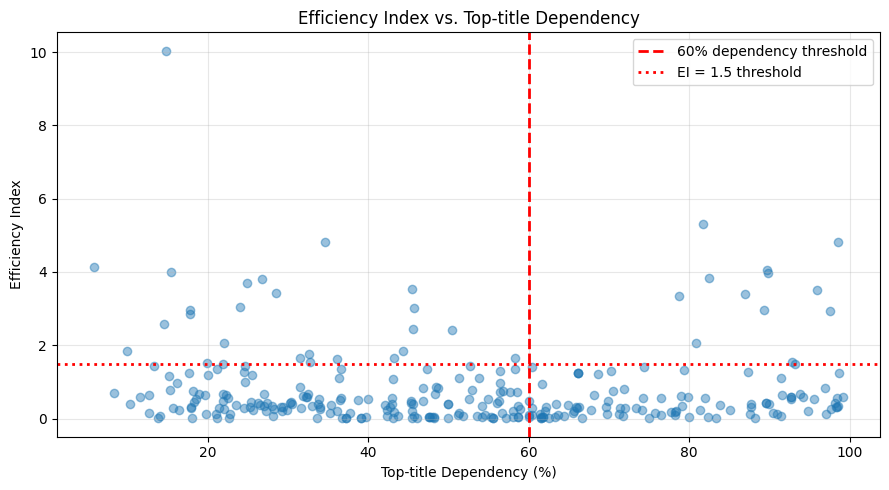

In [14]:
# ============================================================
# 13. EI vs 단일 히트작 의존도 시각화
# ============================================================

# 산점도 생성
plt.figure(figsize=(9, 5))
plt.scatter(
    segment_valid["top_title_dependency"] * 100,
    segment_valid["efficiency_index"],
    alpha=0.45
)

# 단일 히트작 의존도 60% 기준선
plt.axvline(60, color="red", linestyle="--", linewidth=2, label="60% dependency threshold")

# EI 1.5 기준선
plt.axhline(1.5, color="red", linestyle=":", linewidth=2, label="EI = 1.5 threshold")

# 제목과 축 설정
plt.title("Efficiency Index vs. Top-title Dependency")
plt.xlabel("Top-title Dependency (%)")
plt.ylabel("Efficiency Index")

# 범례 표시
plt.legend()

# 격자 표시
plt.grid(alpha=0.3)

# 레이아웃 정리
plt.tight_layout()

# 그래프 출력
plt.show()

### 해석 : EI와 단일 히트작 의존도

- 왼쪽 위 영역은 EI가 높으면서 단일 히트작 의존도가 낮은 상대적으로 안정적인 후보군이다.
- 오른쪽 영역은 특정 작품 1개가 성과를 크게 만든 세그먼트일 가능성이 높다.
- 따라서 같은 EI라도 왼쪽에 있는 세그먼트가 추가 확보 근거로 더 안정적이다.

**인사이트**  
이 그래프는 “효율이 높다”와 “확보 우선순위가 높다”가 항상 같은 의미는 아니라는 점을 보여준다.     
효율성뿐 아니라 반복 가능성과 안정성을 함께 봐야 한다.

### 해석

- 빨간 가로선 위쪽은 **EI 1.5 이상**으로 공급 대비 시청효율이 높은 후보군이다.
- 빨간 세로선 오른쪽은 **단일 타이틀 의존도 60% 이상**으로, 특정 인기작 하나가 세그먼트 전체 성과를 크게 좌우할 가능성이 있는 영역이다.
- 산점도에서 EI가 높더라도 오른쪽에 위치한 세그먼트는 “안정적인 장르 수요”라기보다 “단일 히트작 효과”일 수 있다.

**인사이트**  
효율이 높아 보이는 세그먼트라도 단일 타이틀 의존도가 높으면 추가 콘텐츠 확보의 근거로 삼기 어렵다.      
따라서 우선순위는 EI만으로 결정하지 않고, `matched_titles`, `top_title_dependency`, `rank_score`를 함께 사용한다.

**다음 분석 연결**  
이 기준을 적용해 대륙별로 안정적인 TV Show 확보 후보를 분리해서 확인한다.

## 8. 대륙별 TV Show 확보 우선순위 Top 5

전체 Top 5만 보면 미국 중심 결과가 강하게 나타날 수 있다.  
하지만 콘텐츠 수급 전략은 대륙별 포트폴리오 관점에서도 필요하다.

따라서 최종 결과는 대륙별로 나누어 제시한다.

In [15]:
# ============================================================
# 14. 제작국가를 대륙으로 매핑
# ============================================================

# 주요 제작국가를 대륙으로 매핑
continent_map = {
    "United States": "North America", "Canada": "North America", "Mexico": "North America",
    "Puerto Rico": "North America", "Cuba": "North America", "Dominican Republic": "North America",
    "Jamaica": "North America", "Guatemala": "North America", "Panama": "North America",
    "Costa Rica": "North America",

    "Brazil": "South America", "Argentina": "South America", "Colombia": "South America",
    "Chile": "South America", "Peru": "South America", "Venezuela": "South America",
    "Uruguay": "South America", "Ecuador": "South America",

    "United Kingdom": "Europe", "France": "Europe", "Spain": "Europe", "Germany": "Europe",
    "Italy": "Europe", "Denmark": "Europe", "Norway": "Europe", "Sweden": "Europe",
    "Belgium": "Europe", "Netherlands": "Europe", "Poland": "Europe", "Russia": "Europe",
    "Ireland": "Europe", "Austria": "Europe", "Switzerland": "Europe", "Portugal": "Europe",
    "Finland": "Europe", "Iceland": "Europe", "Greece": "Europe", "Czech Republic": "Europe",
    "Romania": "Europe", "Hungary": "Europe", "Bulgaria": "Europe", "Serbia": "Europe",
    "Croatia": "Europe", "Ukraine": "Europe", "Malta": "Europe", "Cyprus": "Europe",

    "India": "Asia", "Japan": "Asia", "South Korea": "Asia", "China": "Asia",
    "Hong Kong": "Asia", "Taiwan": "Asia", "Singapore": "Asia", "Indonesia": "Asia",
    "Thailand": "Asia", "Philippines": "Asia", "Malaysia": "Asia", "Vietnam": "Asia",
    "Turkey": "Asia", "Israel": "Asia", "Lebanon": "Asia", "Saudi Arabia": "Asia",
    "United Arab Emirates": "Asia", "Iran": "Asia", "Pakistan": "Asia",

    "Nigeria": "Africa", "South Africa": "Africa", "Egypt": "Africa", "Kenya": "Africa",
    "Ghana": "Africa", "Morocco": "Africa", "Algeria": "Africa", "Tunisia": "Africa",
    "Ethiopia": "Africa", "Senegal": "Africa", "Angola": "Africa", "Malawi": "Africa",
    "Mauritius": "Africa",

    "Australia": "Oceania", "New Zealand": "Oceania", "Fiji": "Oceania"
}

# production_country를 continent로 변환
segment_valid["continent"] = segment_valid["production_country"].map(continent_map).fillna("Other")

# Other / Unknown은 최종 대륙별 결과에서 제외
segment_continent = segment_valid[~segment_valid["continent"].isin(["Other"])].copy()

# 대륙별 rank_score Top5 추출
continent_top5 = (
    segment_continent
    .sort_values(["continent", "rank_score"], ascending=[True, False])
    .groupby("continent")
    .head(5)
    .copy()
)

# 출력용 컬럼 선택
display_cols = [
    "production_country", "genre", "type", "matched_titles",
    "supply_weight", "watch_hours", "efficiency_index",
    "top_title_dependency", "rank_score", "evidence_level"
]

# 보기 좋은 출력용 테이블 생성
continent_top5_display = continent_top5[["continent"] + display_cols].copy()
continent_top5_display["supply_weight"] = continent_top5_display["supply_weight"].round(2)
continent_top5_display["watch_hours"] = continent_top5_display["watch_hours"].map(lambda x: f"{x:,.0f}")
continent_top5_display["efficiency_index"] = continent_top5_display["efficiency_index"].round(2)
continent_top5_display["top_title_dependency"] = (continent_top5_display["top_title_dependency"] * 100).round(1).astype(str) + "%"
continent_top5_display["rank_score"] = continent_top5_display["rank_score"].round(2)

# 대륙별 표 출력
for cont in ["Asia", "Europe", "North America", "South America", "Africa", "Oceania"]:
    temp = continent_top5_display[continent_top5_display["continent"] == cont]
    if len(temp) > 0:
        display(Markdown(f"### {cont} — TV Show 확보 우선순위 Top 5"))
        display(temp.drop(columns=["continent"]))

### Asia — TV Show 확보 우선순위 Top 5

,production_country,genre,type,matched_titles,supply_weight,watch_hours,efficiency_index,top_title_dependency,rank_score,evidence_level
392,South Korea,International TV Shows,TV Show,99,51.50,"481,116,667",0.71,8.3%,3.00,Strong
399,South Korea,TV Comedies,TV Show,15,5.86,"98,833,333",1.28,24.6%,2.68,Strong
396,South Korea,Romantic TV Shows,TV Show,49,25.28,"262,466,667",0.79,15.3%,2.62,Strong
398,South Korea,TV Action & Adventure,TV Show,8,2.62,"53,195,833",1.54,32.7%,2.28,Moderate
394,South Korea,Korean TV Shows,TV Show,78,45.17,"345,850,000",0.58,11.6%,2.25,Strong


### Europe — TV Show 확보 우선순위 Top 5

,production_country,genre,type,matched_titles,supply_weight,watch_hours,efficiency_index,top_title_dependency,rank_score,evidence_level
476,United Kingdom,Kids' TV,TV Show,35,17.51,"326,973,889",1.42,13.3%,4.41,Strong
413,Spain,Spanish-Language TV Shows,TV Show,34,12.83,"258,050,000",1.53,19.9%,4.35,Strong
408,Spain,International TV Shows,TV Show,45,16.31,"256,816,667",1.20,20.0%,3.67,Strong
475,United Kingdom,International TV Shows,TV Show,83,40.12,"512,425,000",0.97,16.2%,3.61,Strong
406,Spain,Crime TV Shows,TV Show,23,7.50,"162,991,667",1.65,31.5%,3.59,Strong


### North America — TV Show 확보 우선순위 Top 5

...

,production_country,genre,type,matched_titles,supply_weight,watch_hours,efficiency_index,top_title_dependency,rank_score,evidence_level
101,Colombia,Spanish-Language TV Shows,TV Show,25,8.19,"319,016,667",2.96,17.8%,7.93,Strong
99,Colombia,International TV Shows,TV Show,25,8.53,"319,016,667",2.84,17.8%,7.62,Strong
97,Colombia,Crime TV Shows,TV Show,14,4.69,"227,622,222",3.69,24.9%,7.50,Strong
100,Colombia,Romantic TV Shows,TV Show,5,1.50,"69,883,333",3.54,45.5%,3.46,Moderate
105,Colombia,TV Dramas,TV Show,6,1.89,"45,955,556",1.85,44.3%,2.00,Moderate


### Africa — TV Show 확보 우선순위 Top 5

,production_country,genre,type,matched_titles,supply_weight,watch_hours,efficiency_index,top_title_dependency,rank_score,evidence_level
385,South Africa,International TV Shows,TV Show,6,2.61,"25,038,889",0.73,57.6%,0.60,Moderate
389,South Africa,TV Dramas,TV Show,5,2.62,"24,653,333",0.72,58.5%,0.53,Moderate
135,Egypt,TV Dramas,TV Show,5,4.27,"1,446,667",0.03,39.2%,0.03,Moderate
321,Nigeria,TV Dramas,TV Show,4,3.17,"1,533,333",0.04,58.7%,0.02,Exploratory
132,Egypt,International TV Shows,TV Show,5,5.43,"1,446,667",0.02,39.2%,0.02,Moderate


### Oceania — TV Show 확보 우선순위 Top 5

,production_country,genre,type,matched_titles,supply_weight,watch_hours,efficiency_index,top_title_dependency,rank_score,evidence_level
23,Australia,TV Dramas,TV Show,14,6.48,"93,320,000",1.10,36.4%,1.89,Strong
17,Australia,Kids' TV,TV Show,15,9.46,"107,741,667",0.87,31.6%,1.64,Strong
16,Australia,International TV Shows,TV Show,22,11.08,"51,066,667",0.35,27.0%,0.80,Strong
22,Australia,TV Comedies,TV Show,11,8.12,"58,800,000",0.55,43.0%,0.78,Strong
21,Australia,TV Action & Adventure,TV Show,2,0.33,"6,116,667",1.40,60.5%,0.61,Exploratory


### 해석 : 대륙별 Top5

- 대륙별 표는 전체 순위에서 가려지는 지역별 후보를 분리해서 보여준다.
- 북미는 미국 제작 콘텐츠가 강하고, 아시아는 한국 제작 TV Show, 유럽은 영국·스페인, 남미는 콜롬비아 중심 후보가 나타난다.
- 각 표에서 `matched_titles`, `top_title_dependency`, `evidence_level`을 함께 보면 후보의 근거 수준을 판단할 수 있다.

**인사이트**  
대륙별 Top5는 단순 랭킹이 아니라 지역별 콘텐츠 포트폴리오 전략을 세우기 위한 도구다.       
예를 들어 북미는 규모형 후보, 아시아는 한국 TV Show 중심 후보, 유럽은 언어권·장르 특화 후보로 해석할 수 있다.

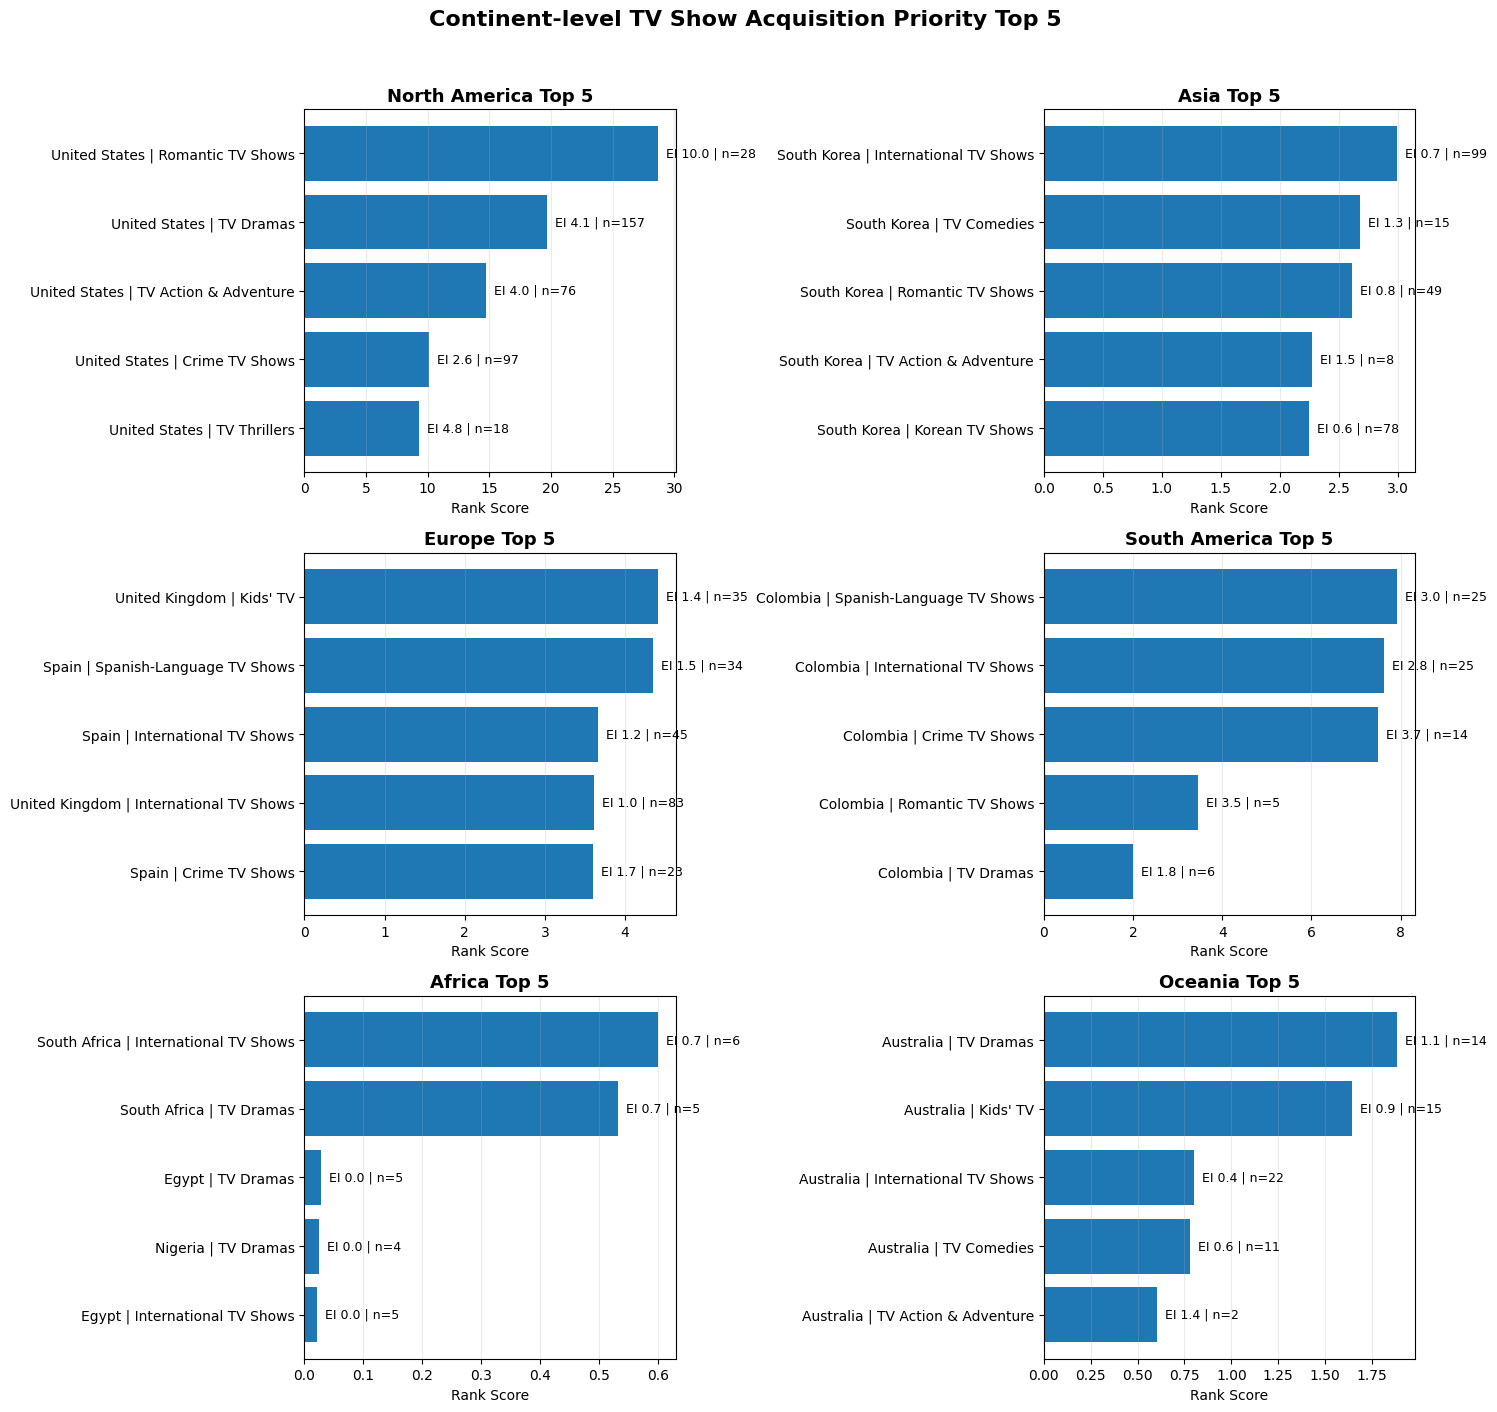

In [16]:
# ============================================================
# 15. 대륙별 Top5 카드형 그래프
# ============================================================

# 표시할 대륙 목록
continents = [c for c in ["North America", "Asia", "Europe", "South America", "Africa", "Oceania"] 
              if c in continent_top5["continent"].unique()]

# subplot 행/열 계산
n = len(continents)
cols = 2
rows = int(np.ceil(n / cols))

# 카드형 그래프 생성
fig, axes = plt.subplots(rows, cols, figsize=(15, 4.6 * rows))
axes = np.array(axes).reshape(-1)

# 대륙별 그래프 생성
for ax, cont in zip(axes, continents):
    # 해당 대륙 Top5 추출
    temp = continent_top5[continent_top5["continent"] == cont].sort_values("rank_score", ascending=True).copy()

    # 라벨 생성: 제작국가 | 장르
    temp["label"] = temp["production_country"] + " | " + temp["genre"]

    # 수평 막대 그래프 생성
    ax.barh(temp["label"], temp["rank_score"])

    # 제목 설정
    ax.set_title(f"{cont} Top 5", fontsize=13, weight="bold")

    # x축 라벨 설정
    ax.set_xlabel("Rank Score")

    # 막대 끝에 EI와 매칭 타이틀 수 표기
    for idx, row in enumerate(temp.itertuples()):
        ax.text(
            row.rank_score,
            idx,
            f"  EI {row.efficiency_index:.1f} | n={int(row.matched_titles)}",
            va="center",
            fontsize=9
        )

    # 격자 표시
    ax.grid(axis="x", alpha=0.25)

# 남는 subplot 숨김
for j in range(len(continents), len(axes)):
    axes[j].axis("off")

# 전체 제목
fig.suptitle("Continent-level TV Show Acquisition Priority Top 5", fontsize=16, weight="bold", y=1.02)

# 레이아웃 정리
plt.tight_layout()

# 그래프 출력
plt.show()

### 해석 : 대륙별 후보 비교

- 카드형 그래프는 대륙별 후보를 분리해 보여주기 때문에, 전체 순위에서 미국 후보가 압도하는 문제를 줄여준다.
- 막대 길이는 `rank_score`를 의미하고, 라벨의 EI와 n은 각각 공급 대비 효율과 근거 타이틀 수를 보여준다.
- 따라서 막대가 길고 n이 충분한 후보가 가장 우선적으로 검토할 만한 세그먼트다.

**인사이트**  
이 시각화는 최종 제안에서 “글로벌 Top5”만 제시하는 대신, 대륙별로 어떤 제작국가·장르 조합을 확보 후보로 볼 수 있는지 설명하는 데 적합하다.

### 대륙별 결과 해석

- **North America**는 미국 제작 `Romantic TV Shows`, `TV Dramas`, `TV Action & Adventure` 등이 높은 rank_score를 보이며, 시청시간 규모와 근거 수준이 모두 강하다.
- **Asia**는 한국 제작 `International TV Shows`, `TV Comedies`, `Romantic TV Shows`, `Korean TV Shows`가 상위에 나타난다. 다만 일부 세그먼트는 EI 자체보다 안정적인 매칭 타이틀 수와 낮은 의존도를 기반으로 후보화된다.
- **Europe**은 영국의 `Kids' TV`, 스페인의 `Spanish-Language TV Shows`, `International TV Shows`, `Crime TV Shows`가 주요 후보로 나타난다.
- **South America**는 콜롬비아 제작 스페인어권·국제 TV Show 계열이 상대적으로 강하게 나타난다.
- **Africa / Oceania**는 후보가 존재하지만 전체적으로 rank_score와 시청시간 규모가 낮아 탐색 후보로 보는 것이 안전하다.

**인사이트**  
전체 Top 순위만 보면 미국 중심으로 결과가 수렴하지만, 대륙별로 나누면 아시아의 한국 TV Show, 유럽의 영국·스페인 TV Show, 남미의 콜롬비아 TV Show처럼 지역별 확보 후보가 드러난다.       
이는 콘텐츠 확보 전략을 “글로벌 단일 Top5”가 아니라 **대륙별 포트폴리오 관점**으로 설계해야 한다는 점을 보여준다.

**다음 분석 연결**  
이후 모델링에서는 이러한 우선순위가 단순 계산 결과에만 의존하는지, 아니면 피처 조합을 통해서도 어느 정도 설명 가능한지 보조 검증한다.

## 9. 모델링: EI 기반 후보를 보조 검증하기

이번 프로젝트의 중심은 머신러닝 모델이 아니라 **Efficiency Index와 Rank Score 기반의 콘텐츠 확보 우선순위 도출**이다.  
다만 EI와 Rank Score만으로는 다음과 같은 질문이 남는다.

1. 공급 대비 시청효율이 높게 나온 후보가 단순 계산 결과에만 의존한 것은 아닌가?
2. 국가·장르·등급·연식·공급량 같은 피처 조합으로도 시청시간 패턴이 어느 정도 설명되는가?
3. 최종 후보가 모델 관점에서도 완전히 동떨어진 결과는 아닌가?

따라서 이 파트의 모델링은 **앞서 도출한 후보가 데이터 패턴상 어느 정도 설명 가능한지 확인하는 보조 검증 장치**로 사용한다.       
단, 대륙 × 제작국가 × 장르 × TV Show로 집계된 265개의 세그먼트 데이터만 사용한 점을 감안한다.

| 구분 | 의미 |
|---|---|
| 모델링 목적 | EI·Rank Score 기반 후보의 보조 검증 |
| 학습 단위 | 대륙 × 제작국가 × 장르 × TV Show 세그먼트 |
| 예측 대상 | 로그 변환된 시청시간 `log1p(watch_hours)` |
| 사용 피처 | 대륙, 제작국가, 장르, 등급, 공급량, 매칭 타이틀 수, 공개연도, 등록연도, 콘텐츠 연식 |
| 해석 기준 | 정확한 수요 예측보다 상위 후보를 어느 정도 포착하는지 확인 |
| 주의점 | 표본 수가 작으므로 모델 결과만으로 콘텐츠 확보 결정을 내리기는 어려움 |

즉, 모델링의 역할은 다음과 같이 정리할 수 있다.

> “EI와 Rank Score로 뽑은 후보가 모델이 보는 데이터 패턴에서도 어느 정도 납득 가능한 후보인지 확인한다.”

### 모델링 데이터 설계

,항목,내용
0,전체 모델링 세그먼트 수,265개
1,학습 세그먼트 수,198개
2,검증 세그먼트 수,67개
3,목표변수,log1p(watch_hours)
4,범주형 피처,"continent, production_country, genre, type, do..."
5,수치형 피처,"supply_weight, matched_titles, median_release_..."


### 모델 성능 비교

,model,RMSE_log,MAE_log,Spearman_rank_corr,Top20_hit_count,Top20_total,Top20_overlap
0,LightGBM,1.467039,1.102376,0.643044,11,13,0.846154
1,Ridge,1.223871,0.905574,0.844321,10,13,0.769231
2,Lasso,1.259918,0.919599,0.814311,9,13,0.692308


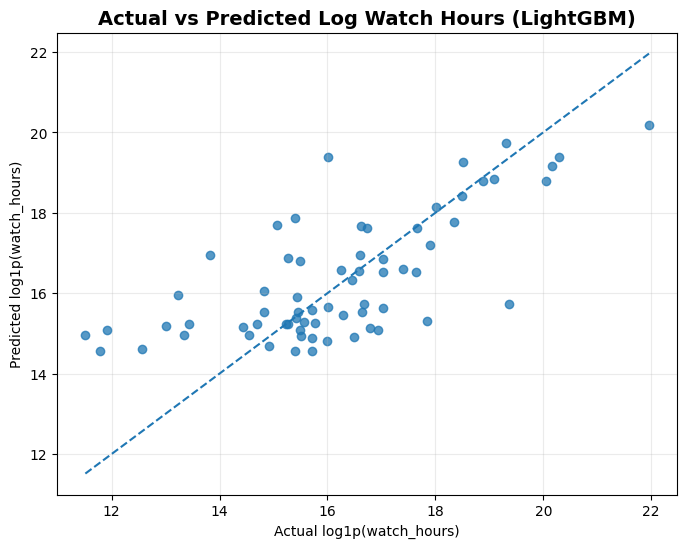

In [17]:
# ============================================================
# 16. 모델링 데이터 준비 및 성능 비교
# ============================================================

# 모델링에 사용할 데이터 선택
# - matched_titles가 1개뿐이면 단일 콘텐츠 영향이 너무 크기 때문에 제외
# - watch_hours가 0이면 시청 패턴을 학습하기 어렵기 때문에 제외
model_df = segment_continent[
    (segment_continent["matched_titles"] >= 2) &
    (segment_continent["watch_hours"] > 0)
].copy()

# 목표변수: 시청시간은 일부 인기 콘텐츠에 크게 쏠리므로 log1p 변환
# log1p(x)는 log(1+x)와 같아, 큰 값의 영향력을 줄여 모델이 안정적으로 학습하도록 돕는다.
model_df["target_log_watch"] = np.log1p(model_df["watch_hours"])

# 범주형 피처 정의
categorical_features = [
    "continent",
    "production_country",
    "genre",
    "type",
    "dominant_rating_group"
]

# 수치형 피처 정의
numeric_features = [
    "supply_weight",
    "matched_titles",
    "median_release_year",
    "median_year_added",
    "median_content_age"
]

# 입력 피처와 목표변수 분리
X = model_df[categorical_features + numeric_features]
y = model_df["target_log_watch"]

# 학습/검증 데이터 분리
# 데이터 수가 많지 않으므로, 해석 시 과신하지 않기 위해 검증 세트를 분리한다.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# 모델링 설계 요약 테이블
modeling_design_df = pd.DataFrame({
    "항목": [
        "전체 모델링 세그먼트 수",
        "학습 세그먼트 수",
        "검증 세그먼트 수",
        "목표변수",
        "범주형 피처",
        "수치형 피처"
    ],
    "내용": [
        f"{len(model_df):,}개",
        f"{len(X_train):,}개",
        f"{len(X_test):,}개",
        "log1p(watch_hours)",
        ", ".join(categorical_features),
        ", ".join(numeric_features)
    ]
})

# 범주형은 원-핫 인코딩, 수치형은 표준화
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numeric_features)
    ]
)

# 비교할 모델 정의
# Ridge / Lasso: 해석 가능한 선형 베이스라인
# LightGBM: 비선형 관계와 피처 간 상호작용을 확인하기 위한 보조 모델
models = {
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.001, max_iter=10000),
    "LightGBM": LGBMRegressor(
        n_estimators=50,
        learning_rate=0.08,
        max_depth=3,
        random_state=42,
        n_jobs=1,
        force_col_wise=True,
        verbose=-1
    )
}

# 결과 저장 리스트와 학습된 모델 저장 딕셔너리
model_results = []
fitted_pipelines = {}
validation_predictions = {}

# 모델별 학습 및 평가
for name, model in models.items():
    # 전처리 + 모델 파이프라인 구성
    pipe = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", model)
    ])

    # 모델 학습
    pipe.fit(X_train, y_train)

    # 검증 데이터 예측
    pred = pipe.predict(X_test)

    # RMSE 계산: 큰 오차에 더 민감한 지표
    rmse = mean_squared_error(y_test, pred) ** 0.5

    # MAE 계산: 평균적으로 얼마나 빗나갔는지 확인하는 지표
    mae = mean_absolute_error(y_test, pred)

    # 실제 순위와 예측 순위의 상관 계산
    # 기존 방식처럼 index가 다른 Series끼리 corr을 계산하면 정렬 오류가 생길 수 있어 numpy array 기준으로 계산한다.
    spearman = pd.Series(y_test.to_numpy()).rank().corr(pd.Series(pred).rank())

    # 상위 20% 세그먼트 overlap 계산
    # 프로젝트 목적이 정확한 예측보다 상위 후보 포착에 가깝기 때문에 함께 확인한다.
    k = max(1, int(len(y_test) * 0.2))
    true_top = set(y_test.sort_values(ascending=False).head(k).index)
    pred_top = set(pd.Series(pred, index=y_test.index).sort_values(ascending=False).head(k).index)
    top20_hit_count = len(true_top & pred_top)
    top20_overlap = top20_hit_count / k

    # 결과 저장
    model_results.append({
        "model": name,
        "RMSE_log": rmse,
        "MAE_log": mae,
        "Spearman_rank_corr": spearman,
        "Top20_hit_count": top20_hit_count,
        "Top20_total": k,
        "Top20_overlap": top20_overlap
    })

    # 학습된 모델과 예측값 저장
    fitted_pipelines[name] = pipe
    validation_predictions[name] = pred

# 결과 테이블 생성
model_results_df = (
    pd.DataFrame(model_results)
    .sort_values(["Top20_overlap", "Spearman_rank_corr"], ascending=False)
    .reset_index(drop=True)
)

# 상위 후보 포착력을 우선 기준으로 best model 선정
best_model_name = model_results_df.iloc[0]["model"]
best_pipe = fitted_pipelines[best_model_name]
best_pred = validation_predictions[best_model_name]

# 결과 출력
display(Markdown("### 모델링 데이터 설계"))
display(modeling_design_df)

display(Markdown("### 모델 성능 비교"))
display(model_results_df)

# 실제값 vs 예측값 시각화
plt.figure(figsize=(8, 6))
plt.scatter(y_test, best_pred, alpha=0.75)

# 대각선 기준선 추가: 실제값과 예측값이 같다면 이 선에 가까워진다.
min_value = min(y_test.min(), best_pred.min())
max_value = max(y_test.max(), best_pred.max())
plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")

plt.title(f"Actual vs Predicted Log Watch Hours ({best_model_name})", fontsize=14, weight="bold")
plt.xlabel("Actual log1p(watch_hours)")
plt.ylabel("Predicted log1p(watch_hours)")
plt.grid(alpha=0.25)
plt.show()

### 해석 : 모델 성능과 역할

이번 모델링에는 **총 265개 세그먼트**가 사용되었다. 이 중 **198개는 학습**, **67개는 검증**에 사용했다.  
즉, 일반적인 머신러닝 프로젝트처럼 수천~수만 건의 데이터를 학습한 것이 아니라, **대륙 × 제작국가 × 장르 단위로 집계된 소규모 세그먼트 데이터**를 활용한 보조 검증에 가깝다.

**모델 성능 비교 확인**

- `Ridge`는 `RMSE_log = 1.224`, `MAE_log = 0.906`, `Spearman = 0.844`로 전체 오차와 순위 방향성에서 가장 안정적이었다.
- `Lasso`도 `RMSE_log = 1.260`, `MAE_log = 0.920`, `Spearman = 0.814`로 Ridge와 비슷하게 전체적인 순위 흐름을 잘 따라갔다.
- 반면 `LightGBM`은 `RMSE_log = 1.467`, `MAE_log = 1.102`, `Spearman = 0.643`으로 전체 예측 오차와 순위 상관은 선형 모델보다 낮았다.
- 다만 `Top20_overlap`에서는 `LightGBM`이 **84.6%**로 가장 높았다. 검증 세트 67개 중 상위 20%는 13개 세그먼트인데, LightGBM은 실제 상위 13개 중 **11개**를 예측 상위권에 함께 포함했다. Ridge는 **10개**, Lasso는 **9개**였다.

**발견한 점**

전체적인 순위 흐름과 평균 오차는 Ridge가 더 안정적이나, 해당 프로젝트의 목적이 모든 세그먼트의 시청시간을 정밀하게 맞히는 것이 아니라     
**Rank Score로 뽑은 확보 후보가 모델 관점에서도 상위권 후보로 볼 수 있는지 점검하는 것**에 가깝다.

따라서 모델 선택 기준도 예측 정확도 자체보다 **상위 후보 포착력**을 더 중요하게 보았다.     
이 관점에서는 LightGBM이 실제 상위권 후보 13개 중 11개를 잡아냈기 때문에, 이후 후보 점검용 모델로 활용했다.

**그래프 해석**

Actual vs Predicted 그래프는 실제 로그 시청시간과 예측 로그 시청시간을 비교한 것이다. 
점들이 대각선에 가까울수록 예측이 잘 맞은 것이다.  
그래프를 보면 일부 점은 대각선 근처에 위치하지만, 전체적으로는 오차가 존재한다. 
이는 현재 모델이 “정교한 수요 예측 모델”로 쓰이기에는 한계가 있다는 뜻이다. 
다만 상위권 후보를 일정 수준 구분하는 데에는 의미가 있으므로, 모델 결과는 **최종 결론을 대체하는 근거가 아니라 Rank Score 결과를 보조 확인하는 장치**로 반영한다.

**인사이트**

모델링 결과를 통해 얻은 결론은 다음과 같다.

> EI와 Rank Score 기반 후보는 모델링 없이도 충분히 설명 가능한 스코어링 결과이다.  
> 다만 LightGBM이 실제 상위 시청 세그먼트 13개 중 11개를 함께 포착했다는 점에서, 최종 후보군이 데이터 패턴상 완전히 동떨어진 결과는 아니라고 볼 수 있다.

즉, 이번 프로젝트에서 모델링은 **스코어링 기반 후보를 한 번 더 점검하는 보조 검증 절차**로 사용하는 것이 적절하다.

### Feature Importance — LightGBM

,feature,importance_mean,importance_std
6,matched_titles,0.662300,0.125010
0,continent,0.086706,0.025826
4,dominant_rating_group,0.073467,0.020262
5,supply_weight,0.034440,0.023134
8,median_year_added,0.021395,0.011735
7,median_release_year,0.001685,0.011293
1,production_country,0.000000,0.000000
3,type,0.000000,0.000000
2,genre,-0.006375,0.014962
9,median_content_age,-0.015391,0.020634


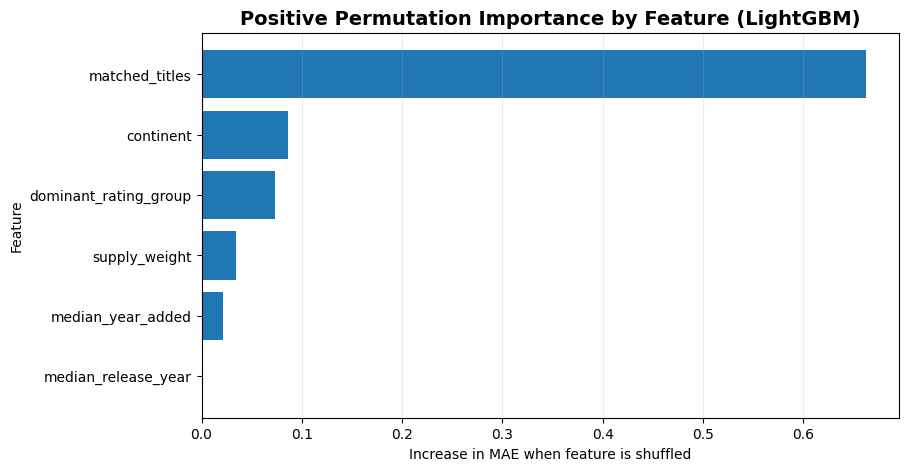

### Rank Score 상위 후보의 모델 관점 점검

※ 아래 예측 순위는 최종 의사결정 기준이 아니라, Rank Score 상위 후보가 모델 관점에서도 어느 정도 상위권에 위치하는지 확인하기 위한 참고 지표다.

,continent,production_country,genre,matched_titles,efficiency_index,top_title_dependency,rank_score,actual_watch_rank,pred_watch_rank,rank_gap
498,North America,United States,Romantic TV Shows,28,10.04,14.8%,28.70,4,5,1
504,North America,United States,TV Dramas,157,4.14,5.9%,19.72,1,3,2
502,North America,United States,TV Action & Adventure,76,4.00,15.4%,14.69,6,3,-3
492,North America,United States,Crime TV Shows,97,2.58,14.6%,10.11,5,10,5
509,North America,United States,TV Thrillers,18,4.83,34.7%,9.29,11,24,13
507,North America,United States,TV Sci-Fi & Fantasy,44,3.04,24.0%,8.78,7,1,-6
506,North America,United States,TV Mysteries,35,3.42,28.5%,8.76,9,8,-1
503,North America,United States,TV Comedies,185,1.83,9.9%,8.62,2,8,6
101,South America,Colombia,Spanish-Language TV Shows,25,2.96,17.8%,7.93,19,32,13
99,South America,Colombia,International TV Shows,25,2.84,17.8%,7.62,19,47,28


In [18]:
# ============================================================
# 17. 모델 해석: 어떤 피처가 예측에 영향을 주었는가?
# ============================================================

from sklearn.inspection import permutation_importance

# Permutation Importance 계산
# 특정 피처를 섞었을 때 예측 성능이 얼마나 나빠지는지 확인한다.
# 값이 클수록 해당 피처가 모델 예측에 더 중요하게 작용했다고 볼 수 있다.
perm_result = permutation_importance(
    best_pipe,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    scoring="neg_mean_absolute_error",
    n_jobs=1
)

# 피처 중요도 테이블 생성
feature_importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
}).sort_values("importance_mean", ascending=False)

# 결과 출력
display(Markdown(f"### Feature Importance — {best_model_name}"))
display(feature_importance_df)

# 중요도가 양수인 피처만 시각화
# 음수 또는 0에 가까운 값은 작은 검증 데이터에서 안정적인 영향력을 확인하기 어렵다는 의미로 해석한다.
plot_importance = (
    feature_importance_df[feature_importance_df["importance_mean"] > 0]
    .sort_values("importance_mean", ascending=True)
    .tail(10)
)

plt.figure(figsize=(9, 5))
plt.barh(plot_importance["feature"], plot_importance["importance_mean"])
plt.title(f"Positive Permutation Importance by Feature ({best_model_name})", fontsize=14, weight="bold")
plt.xlabel("Increase in MAE when feature is shuffled")
plt.ylabel("Feature")
plt.grid(axis="x", alpha=0.25)
plt.show()

# ============================================================
# 18. Rank Score 상위 후보를 모델 관점에서 점검
# ============================================================

# 전체 모델링 대상에 대해 예측값 생성
# 이 값은 최종 의사결정 기준이 아니라, Rank Score 후보가 모델 관점에서도 상위권인지 확인하기 위한 참고값이다.
model_check = model_df.copy()
model_check["pred_log_watch"] = best_pipe.predict(X)

# 실제 시청시간 순위와 모델 예측 순위 계산
model_check["actual_watch_rank"] = model_check["watch_hours"].rank(ascending=False, method="min")
model_check["pred_watch_rank"] = model_check["pred_log_watch"].rank(ascending=False, method="min")
model_check["rank_gap"] = model_check["pred_watch_rank"] - model_check["actual_watch_rank"]

# Rank Score 상위 후보 중 모델 예측 순위까지 함께 확인
candidate_model_check = (
    model_check
    .sort_values("rank_score", ascending=False)
    .head(10)
    [[
        "continent", "production_country", "genre", "matched_titles",
        "efficiency_index", "top_title_dependency", "rank_score",
        "actual_watch_rank", "pred_watch_rank", "rank_gap"
    ]]
    .copy()
)

# 보기 좋은 형태로 가공
candidate_model_check["efficiency_index"] = candidate_model_check["efficiency_index"].round(2)
candidate_model_check["top_title_dependency"] = (candidate_model_check["top_title_dependency"] * 100).round(1).astype(str) + "%"
candidate_model_check["rank_score"] = candidate_model_check["rank_score"].round(2)
candidate_model_check["actual_watch_rank"] = candidate_model_check["actual_watch_rank"].astype(int)
candidate_model_check["pred_watch_rank"] = candidate_model_check["pred_watch_rank"].astype(int)
candidate_model_check["rank_gap"] = candidate_model_check["rank_gap"].astype(int)

# 결과 출력
display(Markdown("### Rank Score 상위 후보의 모델 관점 점검"))
display(Markdown("※ 아래 예측 순위는 최종 의사결정 기준이 아니라, Rank Score 상위 후보가 모델 관점에서도 어느 정도 상위권에 위치하는지 확인하기 위한 참고 지표다."))
display(candidate_model_check)

### 해석 : 모델이 중요하게 본 피처와 최종 후보 점검

Permutation Importance는 특정 피처를 일부러 섞었을 때 모델의 예측 오차가 얼마나 커지는지 확인하는 방식이다.  
값이 클수록 모델이 해당 피처를 예측에 더 많이 활용했다는 뜻이다.

**Feature Importance에서 확인한 점**

- 가장 중요한 피처는 `matched_titles`였다. 중요도는 **0.662**로 나타났다.
- 다음으로 `continent`가 **0.087**, `dominant_rating_group`이 **0.073**, `supply_weight`가 **0.034** 수준이었다.
- `matched_titles`의 중요도는 두 번째 피처인 `continent`보다 약 **7.6배** 높다.
- 반면 `production_country`와 `type`은 **0.000**으로 나타났고, `genre`와 `median_content_age`는 0보다 낮게 나타났다.

**발견한 점**

모델은 특정 국가명이나 장르명 자체보다, **해당 세그먼트에 실제로 매칭된 타이틀 수가 충분한지**를 가장 중요하게 보았다.  
이는 현재 데이터 구조상 Engagement Report와 Kaggle 데이터가 완전히 1:1로 매칭되지 않았고, 세그먼트별 시청시간은 결국 “얼마나 많은 콘텐츠가 실제 시청 데이터와 연결되었는가”에 크게 영향을 받기 때문이다.

즉, 모델은 다음과 같은 판단을 하고 있다고 볼 수 있다.

> “이 세그먼트가 정말 시청시간이 높은 패턴인지 판단하려면, 국가명이나 장르명보다 먼저 그 세그먼트를 뒷받침하는 매칭 타이틀 수가 충분한지 확인해야 한다.”

이 점은 앞서 Rank Score에서 `matched_titles`와 `top_title_dependency`를 함께 반영한 이유와 연결된다.     
단순히 EI가 높아도 매칭 타이틀 수가 적거나, 특정 한 편의 콘텐츠에 시청시간이 몰려 있다면 안정적인 확보 후보라고 보기 어렵다.     
모델 관점에서도 `matched_titles`가 가장 중요하게 나타났기 때문에, 최종 후보를 판단할 때 **효율성 + 근거 규모 + 안정성**을 함께 보는 방식이 타당하다고 해석할 수 있다.

**후보 점검표에서 확인한 점**

Rank Score 상위 10개 후보를 모델 예측 순위와 함께 비교하면, 미국 계열 후보는 대부분 실제 시청 순위와 예측 순위가 모두 상위권에 위치한다.

- `United States × Romantic TV Shows`는 Rank Score **28.70**으로 1위였고, 실제 시청 순위 **4위**, 모델 예측 순위 **5위**로 나타났다.      
- `United States × TV Dramas`는 Rank Score **19.72**, 실제 시청 순위 **1위**, 예측 순위 **3위**였다.        
- `United States × TV Action & Adventure`는 Rank Score **14.69**, 실제 시청 순위 **6위**, 예측 순위 **3위**였다.        
- `United States × TV Sci-Fi & Fantasy`는 실제 시청 순위 **7위**였지만, 예측 순위는 **1위**로 더 높게 나타났다.      

반면 콜롬비아 후보는 Rank Score 기준으로는 상위 10위 안에 포함되지만, 모델 예측 순위에서는 상대적으로 낮게 나타났다.

- `Colombia × Spanish-Language TV Shows`는 실제 시청 순위 **19위**, 예측 순위 **32위**였다.     
- `Colombia × International TV Shows`는 실제 시청 순위 **19위**, 예측 순위 **47위**였다.    

**인사이트**

이 차이는 최종 액션을 나눠서 해석해야 한다는 의미다.

1. **미국 제작 TV Show 후보**는 Rank Score, 실제 시청 순위, 모델 예측 순위가 모두 비교적 일관된다. 따라서 “안정적 확보 후보”로 볼 수 있다.
2. **콜롬비아 제작 Spanish-Language / International TV Shows 후보**는 EI와 Rank Score에서는 매력적이지만, 모델 관점에서는 미국 후보만큼 강하게 포착되지 않는다. 따라서 “즉시 대규모 투자 후보”라기보다는 **지역 특화 수요를 확인하는 실험 후보**로 보는 것이 적절하다.
3. `matched_titles`가 모델에서 가장 중요하게 나타났기 때문에, 향후 실제 의사결정에서는 EI가 높은 후보라도 매칭 타이틀 수와 단일 히트작 의존도를 함께 확인해야 한다.

**최종 해석**

따라서 모델링 결과는 다음 결론으로 반영한다.

> 모델링은 최종 후보를 새롭게 선정하기 위한 핵심 방법론은 아니다.  
> 다만 Rank Score 상위 후보 중 미국 제작 TV Show 계열은 모델 관점에서도 상위권으로 확인되므로 안정적 후보로 볼 수 있다.  
> 반면 콜롬비아 계열 후보는 스코어링상 매력은 있지만 모델 예측 순위가 낮기 때문에, 지역 특화 콘텐츠 실험 후보로 분리해 검토하는 것이 더 적절하다.

즉, 최종 의사결정은 모델 예측값 하나로 결정하지 않고, **EI·Rank Score·매칭 타이틀 수·단일 히트작 의존도·모델 예측 순위**를 함께 보는 방식으로 정리할 수 있다.

## 10. 최종 비즈니스 액션

| 대륙 | 추천 액션 | 판단 근거 | 주의점 |
|---|---|---|---|
| North America | 미국 제작 TV Drama / Action / Romance 계열 우선 검토 | 시청시간 규모와 rank_score가 높게 나타나는 경향 | 이미 공급량도 많아 차별화된 하위 장르 검토 필요 |
| Asia | 한국 제작 International TV Shows / Korean TV Shows / Romantic TV Shows 검토 | 공급 대비 글로벌 시청효율 후보로 나타날 가능성 | 소비국가 선호가 아니라 제작국가 기반 성과로 해석 |
| Europe | 영국·스페인 제작 Kids TV / Spanish-Language TV Shows / International TV Shows 검토 | 대륙 내 언어권·장르 다양성이 반영된 후보군 | 국가별 표본 수와 언어권 차이 고려 |
| South America | 콜롬비아·브라질 등 스페인어/라틴계 TV Show 후보 검토 | 전체 Top에는 덜 보이지만 대륙별로 보면 후보가 드러남 | 표본 수와 단일 히트작 의존도 점검 필요 |
| Africa / Oceania | 탐색 후보로 유지 | 일부 세그먼트가 높게 나올 수 있음 | 표본 수가 적으면 의사결정 근거로는 약함 |

### 최종 제안

콘텐츠 확보 후보는 다음 순서로 검토한다.

1. EI가 1.5 이상인지 확인
2. 매칭 타이틀 수가 충분한지 확인
3. 단일 히트작 의존도가 60% 이하인지 확인
4. 대륙별 포트폴리오 균형을 고려
5. 모델링 결과에서도 상위 랭킹으로 유지되는지 확인

## 11. 분석의 한계

| 한계 | 의미 | 대응 |
|---|---|---|
| 제작국가 기준 | 시청자가 어느 국가에 있는지는 알 수 없음 | “소비국가 선호”가 아니라 “제작국가 기반 글로벌 성과”로 해석 |
| 데이터 시점 차이 | Kaggle은 2021년까지, Engagement Report는 2023년 상반기 | 조인 가능한 콘텐츠의 제한적 분석으로 해석 |
| title_key 기반 조인 | 제목 정제 과정에서 오매칭 또는 미매칭 가능 | 시즌 정규화 규칙을 문서화하고 결과 해석 시 주의 |
| 시청시간 쏠림 | 인기작 1개가 세그먼트 전체를 왜곡할 수 있음 | top_title_dependency와 민감도 분석 적용 |
| 대륙별 표본 차이 | 일부 대륙은 매칭 타이틀 수가 적음 | 대륙별 Top5는 표본 수와 근거 수준을 함께 해석 |
| 실제 수익/비용 부재 | 콘텐츠 단가나 수익 자료 없음 | 이번 발표에서는 시청시간 기반 우선순위까지만 제안 |

### 마무리 결론

> Net-Hub의 분석은 콘텐츠 확보 의사결정을 공급량 중심에서 벗어나  
> **공급 대비 시청효율과 지역 포트폴리오 관점으로 전환하는 시도**다.  
> 다만 이번 결과는 소비국가가 아닌 제작국가 기준이며,  
> 실제 투자 결정 전에는 최신 카탈로그·국가별 시청 데이터·콘텐츠 비용 데이터를 추가로 결합해야 한다.